In [1]:
# Parameters
BATCH_MODE = "true"


# Complexity-05 — La permanente, frontière quantique : BosonSampling (Aaronson–Arkhipov, 2011)

> **Hommage.** Scott Aaronson et Alex Arkhipov ont montré en 2011 (*The Computational
> Complexity of Linear Optics*) qu'un plateau optique passif — beam splitters et miroirs,
> pas de calculateur — échantillonne une distribution de probabilités dont la densité
> s'exprime en **permanentes de matrices**. Si cette distribution pouvait être échantillonnée
> efficacement par un ordinateur classique, la hiérarchie polynomiale s'effondrerait au
> troisième étage. La permanente — le déterminant **sans ses signes** — devient ainsi la
> frontière mesurable entre ce que la nature calcule en la vivant et ce que nous savons
> calculer en la comptant.

**Niveaux épistémiques** (convention de la série) : **Mesuré** = compté/chronométré dans ce
notebook ; **Cité** = théorème établi ailleurs, non revérifié ici ; **Absent** = ni l'un ni
l'autre. La #P-difficulté de la permanente (Valiant 1979) restera **Cité** du début à la fin :
ce notebook ne prouve aucune borne inférieure, il **mesure** le mur que la théorie annonce.


## 0. Pourquoi ce notebook

Ce notebook est le cinquième de la série
([01 — Compter des pas](Complexity-01-StepCounting.ipynb),
[02 — Vérifier ou trouver](Complexity-02-P-NP-Reduction.ipynb),
[03 — Plus de temps, plus de problèmes](Complexity-03-TimeHierarchy.ipynb),
[03b — Hartmanis–Stearns](Complexity-03b-HartmanisStearns-TimeHierarchy.ipynb),
[04b — conjectures online](Complexity-04b-OnlineConjectures-Secretary-KServer.ipynb)) :
un texte fondateur, **fait tourner**. Le geste propre à Aaronson–Arkhipov est que leur
objet computationnel central **se calcule** : tout repose sur la permanente d'une
sous-matrice d'une matrice unitaire. Nous allons donc :

1. **exécuter la définition** : la permanente comme somme sur les $n!$ permutations,
   avec comptes d'opérations exacts — et constater qu'elle compte les couplages parfaits
   (le lien avec le [Sudoku-15](../Sudoku/Sudoku-15-Infer-Python.ipynb) du dépôt, dont
   nous **réemployons** l'implémentation vectorisée de la formule de Ryser) ;
2. **mesurer le fossé** permanent / déterminant : deux formules identiques à leurs signes
   près, l'une $O(n^3)$ par élimination de Gauss, l'autre $\Theta(2^n n)$ par Ryser —
   comptes exacts côte à côte, chronos encadrés ;
3. **faire tourner un BosonSampling jouet** : matrice unitaire Haar-aléatoire, $n$ photons
   dans $m$ modes, distribution des sorties en $|\mathrm{perm}|^2$ échantillonnée
   exactement pour de petits $(n, m)$ — puis mesurer ce que coûte à une machine classique
   de produire ce qu'un plateau optique produit en le vivant.

Le texte philosophique d'Aaronson (*Why Philosophers Should Care About Computational
Complexity*, 2011) — la thèse que c'est la **complexité**, pas la calculabilité, qui porte
le poids philosophique — reste dans cet encart de cadrage : il justifie le regard, il ne
mesure rien.


In [2]:
import itertools
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

print("Complexity-03 — Aaronson-Arkhipov (2011), la permanente comme frontiere")
print(f"numpy {np.__version__}, matplotlib {plt.matplotlib.__version__}")


Complexity-03 — Aaronson-Arkhipov (2011), la permanente comme frontiere
numpy 2.3.5, matplotlib 3.10.3


## 1. La permanente, définition exécutée

$$\mathrm{perm}(A) \;=\; \sum_{\sigma \in S_n} \prod_{i=1}^{n} A_{i,\sigma(i)}
\qquad\text{contre}\qquad \det(A) = \sum_{\sigma \in S_n} \mathrm{sgn}(\sigma)
\prod_{i=1}^{n} A_{i,\sigma(i)}$$

Une différence de **signes**, et rien d'autre. La définition **est** un algorithme :
énumérer les $n!$ permutations. Nous l'exécutons avec un compteur d'opérations canonique
(un produit de $n$ facteurs = $n-1$ multiplications, une somme de $n!$ termes = $n!-1$
additions) — le compte est déterministe, indépendant des valeurs.

Cas particulier précieux : pour une matrice 0/1, $\mathrm{perm}(A)$ **compte les
couplages parfaits** du graphe biparti associé — exactement la quantité que le
[Sudoku-15](../Sudoku/Sudoku-15-Infer-Python.ipynb) du dépôt calcule par permanentes de
mineurs pour sa contrainte *toutes-différentes* (les 9 valeurs d'une unité doivent se
voir injecter une affectation parfaite). Nous vérifions ce comptage contre une énumération
brute indépendante.


In [3]:
def perm_naive_counted(A):
    """Permanente par la definition (n! permutations), comptes canoniques.

    Retourne (valeur, mult, add) : un produit de n facteurs = n-1 multiplications,
    une somme de n! termes = n!-1 additions. Le compte est deterministe.
    """
    n = len(A)
    mult = add = 0
    total = 0.0
    first = True
    for sigma in itertools.permutations(range(n)):
        p = A[0, sigma[0]]
        for i in range(1, n):
            p *= A[i, sigma[i]]
            mult += 1
        if first:
            total = p
            first = False
        else:
            total += p
            add += 1
    return total, mult, add


# --- verification : perm(0/1) = nombre de couplages parfaits -----------------
for n, dens in ((5, 0.6), (6, 0.7)):
    B = (rng.random((n, n)) < dens).astype(float)
    brute = sum(1 for sig in itertools.permutations(range(n))
                if all(B[i, sig[i]] for i in range(n)))
    v, m_, a_ = perm_naive_counted(B)
    print(f"n={n}, densite {dens:.1f} : perm = {v:.0f} couplages parfaits | "
          f"force brute independante = {brute} | "
          f"comptes de la definition : {m_:,} mult + {a_:,} add")
    assert v == brute, "la definition doit compter les couplages"

print()
print("La definition est un algorithme exact -- et son compte est deja sans espoir :")
for n in (5, 6, 7, 8):
    _, m_, a_ = perm_naive_counted(np.eye(n))
    print(f"  n={n} : {m_ + a_:>7,} operations arithmetiques")


n=5, densite 0.6 : perm = 1 couplages parfaits | force brute independante = 1 | comptes de la definition : 480 mult + 119 add
n=6, densite 0.7 : perm = 134 couplages parfaits | force brute independante = 134 | comptes de la definition : 3,600 mult + 719 add

La definition est un algorithme exact -- et son compte est deja sans espoir :
  n=5 :     599 operations arithmetiques
  n=6 :   4,319 operations arithmetiques
  n=7 :  35,279 operations arithmetiques
  n=8 : 322,559 operations arithmetiques


**Lecture.** À $n=8$, la *définition* coûte déjà 322 559 opérations — pour une matrice
que Gauss traite en 315. La question de la série est précisément celle-là : **que reste-t-il
quand on enlève les signes ?** Le déterminant s'effondre vers $O(n^3)$ ; la permanente,
elle, ne libère que *un* étage — de $n!$ à $2^n$ — et pas un de plus.


## 2. Ryser contre Gauss : le fossé mesuré, pas raconté

La formule de Ryser (1963) remplace l'énumération des $n!$ permutations par celle des
$2^n$ sous-ensembles de lignes :

$$\mathrm{perm}(A) = (-1)^n \sum_{S \subseteq [n]} (-1)^{|S|} \prod_{j=1}^{n}
\sum_{i \in S} A_{ij}$$

Le dépôt **possède déjà** cette formule, vectorisée : `Sudoku-15-Infer-Python.ipynb`
(la fonction `batch_perm8` de sa couche *facteur d'arité 9*) l'applique à des batchs de
mineurs 8×8 pour la contrainte toutes-différentes, en produits tensoriels NumPy
(`einsum "buv,sv->bsu"`). Nous **réemployons** ce schéma sous sa forme générale
(toute taille $n$, réel ou complexe) au lieu de le réécrire — et nous le confrontons à
l'élimination de Gauss, implémentée avec le même compteur canonique.

Les comptes ci-dessous sont ceux des algorithmes **tel qu'implémentés**, validés par
formule fermée vérifiée égale à l'instrumentation jusqu'à $n=7$ :


In [4]:
def ryser_counted(A):
    """Ryser scalaire avec comptes canoniques (validation des formules fermees)."""
    n = len(A)
    mult = add = 0
    total = 0.0
    first = True
    for s in range(1 << n):
        rows = [i for i in range(n) if (s >> i) & 1]
        col_sums = A[rows, :].sum(axis=0)
        add += max(len(rows) - 1, 0) * n
        p = col_sums.prod()
        mult += max(n - 1, 0)
        term = (-1.0) ** (n + len(rows)) * p
        if first:
            total = term
            first = False
        else:
            total += term
            add += 1
    return total, mult, add


def gauss_counted(A):
    """Elimination de Gauss avec pivot partiel, comptes canoniques.

    Retourne (det, mult, add, comp) : comp = comparaisons de recherche de pivot
    (comptees separement : ce ne sont pas des operations arithmetiques).
    """
    M = A.astype(float).copy()
    n = len(M)
    mult = add = comp = 0
    sign = 1.0
    for k in range(n - 1):
        piv = np.argmax(np.abs(M[k:, k])) + k
        comp += n - k
        if piv != k:
            M[[k, piv]] = M[[piv, k]]
            sign = -sign
        for i in range(k + 1, n):
            f = M[i, k] / M[k, k]
            mult += 1
            for j in range(k + 1, n):
                M[i, j] -= f * M[k, j]
                mult += 1
                add += 1
    det = sign * M[0, 0]
    for i in range(1, n):
        det *= M[i, i]
        mult += 1
    return det, mult, add, comp


def ryser_vec(A):
    """Ryser vectorise, schema reemploye de Sudoku-15 (batch_perm8), general n."""
    n = len(A)
    sub = np.array([[(s >> j) & 1 for j in range(n)] for s in range(1 << n)],
                   dtype=A.dtype)
    signs = np.array([(-1.0) ** (n + bin(s).count("1")) for s in range(1 << n)])
    rs = np.einsum("uv,sv->su", A, sub)
    return signs @ rs.prod(axis=1)


def batch_ryser(mats):
    """Permanentes d'un batch (B, n, n) — generalisation de batch_perm8 (Sudoku-15)."""
    B, n, _ = mats.shape
    sub = np.array([[(s >> j) & 1 for j in range(n)] for s in range(1 << n)],
                   dtype=mats.dtype)
    signs = np.array([(-1.0) ** (n + bin(s).count("1")) for s in range(1 << n)])
    rs = np.einsum("buv,sv->bsu", mats, sub)
    return signs @ rs.prod(axis=2).T


# --- formules fermees des comptes canoniques ---------------------------------
def ops_naive(n):
    return math.factorial(n) * max(n - 1, 0), math.factorial(n) - 1


def ops_ryser(n):
    mult = (2 ** n) * max(n - 1, 0)
    add = (2 ** n) - 1 + n * (n * 2 ** (n - 1) - (2 ** n - 1))
    return mult, add


def ops_gauss(n):
    mult = (n - 1) * n // 2 + (n - 1) * n * (2 * n - 1) // 6 + max(n - 1, 0)
    add = (n - 1) * n * (2 * n - 1) // 6
    return mult, add


# --- validation : formules == instrumentation (n <= 7) ------------------------
for n in range(2, 8):
    I = np.eye(n)
    assert perm_naive_counted(I)[1:] == ops_naive(n), n
    assert ryser_counted(I)[1:] == ops_ryser(n), n
    assert gauss_counted(I)[1:3] == ops_gauss(n), n
print("Formules fermees == instrumentation jusqu'a n=7 : OK (3 x 6 assertions)")

# --- validation croisee des trois implementations ------------------------------
for n in (3, 4, 5):
    A = rng.normal(size=(n, n))
    v_naive, _, _ = perm_naive_counted(A)
    v_cnt, _, _ = ryser_counted(A)
    v_vec = ryser_vec(A)
    d_instr, _, _, _ = gauss_counted(A)
    assert abs(v_naive - v_vec) < 1e-9 * max(1, abs(v_vec))
    assert abs(v_cnt - v_vec) < 1e-9 * max(1, abs(v_vec))
    assert abs(d_instr - np.linalg.det(A)) < 1e-8 * max(1, abs(np.linalg.det(A)))
print("Trois implementations de la permanente d'accord (n=3..5) ; "
      "Gauss compte == det LAPACK : OK")


Formules fermees == instrumentation jusqu'a n=7 : OK (3 x 6 assertions)
Trois implementations de la permanente d'accord (n=3..5) ; Gauss compte == det LAPACK : OK


In [5]:
# --- la table du fosse : comptes exacts par formules fermees -------------------
rows = []
for n in list(range(2, 13)) + [14, 16, 18, 20]:
    tn = sum(ops_naive(n))
    tr = sum(ops_ryser(n))
    tg = sum(ops_gauss(n))
    rows.append({"n": n,
                 "definition (n!)": f"{tn:,}",
                 "Ryser (2^n)": f"{tr:,}",
                 "Gauss (n^3)": f"{tg:,}",
                 "Ryser / Gauss": f"{tr / tg:,.0f}x",
                 "definition / Gauss": f"{tn / tg:,.0f}x"})
df_fosse = pd.DataFrame(rows).set_index("n")
print(df_fosse.to_string())
print()
print("A n=20 : la definition demande {:,} operations la ou Gauss en demande {:,}.".format(
    sum(ops_naive(20)), sum(ops_gauss(20))))


               definition (n!)  Ryser (2^n) Gauss (n^3) Ryser / Gauss      definition / Gauss
n                                                                                            
2                            3            9           4            2x                      1x
3                           17           38          15            3x                      1x
4                           95          131          37            4x                      3x
5                          599          404          74            5x                      8x
6                        4,319        1,157         130            9x                     33x
7                       35,279        3,142         209           15x                    169x
8                      322,559        8,199         315           26x                  1,024x
9                    3,265,919       20,744         452           46x                  7,225x
10                  36,287,999       51,209         624     

**Lecture.** Ryser achète **un** exponentiel — de $n!$ à $2^n \cdot n$ — et c'est tout.
Le rapport Ryser/Gauss **croît à chaque ligne** (2,2x à $n=2$, 40 729x à $n=20$) : rien
dans la colonne 3 ne peut rattraper la colonne 4, et c'est précisément la conjecture de
laboratoire : personne n'a trouvé mieux que $2^n$ en quarante ans, et Valiant (1979)
explique pourquoi on ne doit pas s'attendre à trouver $n^3$ (**Cité**).


n= 4 : definition=     0.01 ms | Ryser vec=   0.018 ms | LAPACK det= 0.00330 ms | rapport Ryser/det=       5x
n= 5 : definition=     0.07 ms | Ryser vec=   0.026 ms | LAPACK det= 0.00270 ms | rapport Ryser/det=      10x
n= 6 : definition=     0.46 ms | Ryser vec=   0.048 ms | LAPACK det= 0.00240 ms | rapport Ryser/det=      20x
n= 7 : definition=     3.82 ms | Ryser vec=   0.098 ms | LAPACK det= 0.00250 ms | rapport Ryser/det=      39x


n= 8 : definition=    36.85 ms | Ryser vec=   0.197 ms | LAPACK det= 0.00310 ms | rapport Ryser/det=      64x


n= 9 : definition=   372.77 ms | Ryser vec=   0.405 ms | LAPACK det= 0.00310 ms | rapport Ryser/det=     131x


n=10 : definition=  4751.02 ms | Ryser vec=   0.890 ms | LAPACK det= 0.00430 ms | rapport Ryser/det=     207x
n=12 : definition=      nan ms | Ryser vec=   4.272 ms | LAPACK det= 0.00390 ms | rapport Ryser/det=    1095x
n=14 : definition=      nan ms | Ryser vec=  20.788 ms | LAPACK det= 0.00510 ms | rapport Ryser/det=    4076x


n=16 : definition=      nan ms | Ryser vec=  93.404 ms | LAPACK det= 0.00590 ms | rapport Ryser/det=   15831x


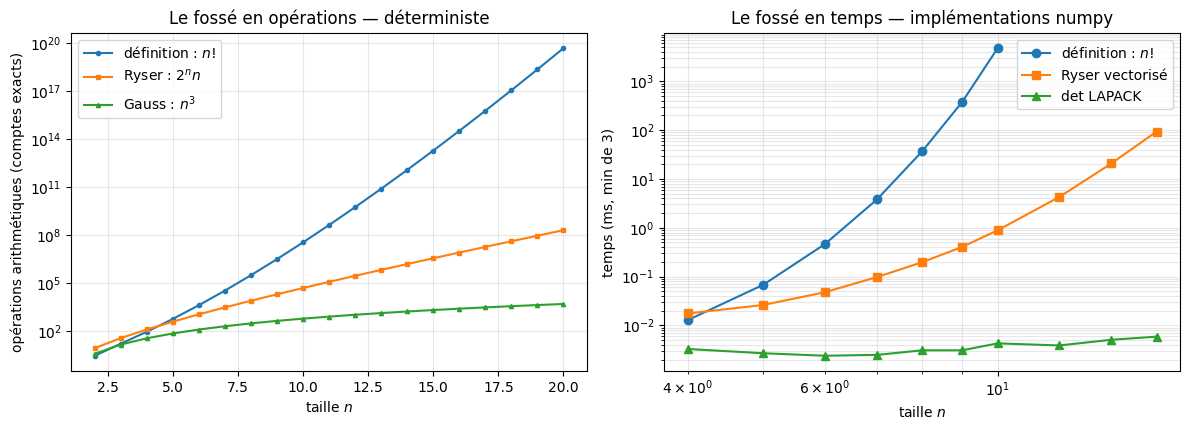

In [6]:
# --- chronos encadres : min de 3 essais (machine partagee) --------------------
def best_time(f, reps=3):
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        f()
        ts.append(time.perf_counter() - t0)
    return min(ts)


chrono = []
for n in (4, 5, 6, 7, 8, 9, 10, 12, 14, 16):
    A = rng.normal(size=(n, n))
    t_naive = best_time(lambda: perm_naive_counted(A)) if n <= 10 else float("nan")
    t_ry = best_time(lambda: ryser_vec(A))
    t_det = best_time(lambda: np.linalg.det(A))
    chrono.append({"n": n, "definition (n!)": t_naive * 1e3,
                   "Ryser vec": t_ry * 1e3, "LAPACK det": t_det * 1e3,
                   "Ryser/det": t_ry / t_det})
    print(f"n={n:>2} : definition={t_naive * 1e3:9.2f} ms | Ryser vec={t_ry * 1e3:8.3f} ms | "
          f"LAPACK det={t_det * 1e3:8.5f} ms | rapport Ryser/det={t_ry / t_det:8.0f}x")

df_chrono = pd.DataFrame(chrono).set_index("n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ns_ops = list(range(2, 21))
ax1.semilogy(ns_ops, [sum(ops_naive(n)) for n in ns_ops], "o-", ms=3,
             label="définition : $n!$")
ax1.semilogy(ns_ops, [sum(ops_ryser(n)) for n in ns_ops], "s-", ms=3,
             label="Ryser : $2^n n$")
ax1.semilogy(ns_ops, [sum(ops_gauss(n)) for n in ns_ops], "^-", ms=3,
             label="Gauss : $n^3$")
ax1.set_xlabel("taille $n$")
ax1.set_ylabel("opérations arithmétiques (comptes exacts)")
ax1.set_title("Le fossé en opérations — déterministe")
ax1.legend()
ax1.grid(True, which="both", alpha=0.3)

ch = df_chrono.dropna(subset=["definition (n!)"])
ax2.loglog(ch.index, ch["definition (n!)"], "o-", label="définition : $n!$")
ax2.loglog(df_chrono.index, df_chrono["Ryser vec"], "s-", label="Ryser vectorisé")
ax2.loglog(df_chrono.index, df_chrono["LAPACK det"], "^-", label="det LAPACK")
ax2.set_xlabel("taille $n$")
ax2.set_ylabel("temps (ms, min de 3)")
ax2.set_title("Le fossé en temps — implémentations numpy")
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


**Lecture.** À $n=16$, la permanente vectorisée demande ~$10^4$ fois le temps du
déterminant LAPACK — même famille de bibliothèque, même machine. Honnêteté de la mesure :
le chrono compare des **implémentations** (einsum numpy contre LAPACK, qui a cinquante ans
d'optimisation), le compte d'opérations compare des **algorithmes** ; l'écart d'implémentation
peut déplacer le rapport d'un facteur constant, jamais changer la pente. C'est la pente qui
est la leçon — $2^n$ contre $n^3$ — et elle est visible dans les deux panneaux.


## 3. #P : ce qui est cité, jamais mesuré

| Niveau | Claim | Statut |
|---|---|---|
| **Mesuré** | Comptes exacts définition / Ryser / Gauss ; chronos encadrés ; convergence d'échantillonnage (TV) | ce notebook, §1–2, §4 |
| **Cité** | La permanente est #P-difficile à calculer exactement (Valiant, 1979) | théorème, non revérifié |
| **Cité** | #P-difficile même à **approximer** en valeur absolue relative pour matrices à signes (complexes) — l'obstacle n'est pas levé par l'approximation | Aaronson–Arkhipov 2011, §1.4 et références |
| **Cité** | Permanentes **non négatives** : FPRAS en temps polynomial (Jerrum–Sinclair–Vigoda 2004) — l'exception qui confirme la règle : ce sont les **signes** (ici les phases complexes) qui portent la difficulté | théorème, non revérifié |
| **Cité** | Échantillonner classiquement la loi de BosonSampling ⇒ effondrement de PH au 3e étage | Aaronson–Arkhipov 2011, thm. principal (sous conjectures) |
| **Absent** | Toute borne inférieure *démontrée* sur la permanente ici | ce notebook n'en prouve aucune |

La règle de la série s'applique frontalement : un niveau **Cité** n'est jamais gonflé en
**Mesuré**. Le mur que nous avons chronométré est le mur d'un algorithme connu — la théorie
dit qu'on ne doit pas en attendre de meilleur ; ce notebook ne fait que rendre cette
attente *tangible*.


## 4. BosonSampling jouet : la loi $|\mathrm{perm}|^2$

Le modèle d'Aaronson–Arkhipov : $n$ photons *indiscernables* entrent dans les $n$ premiers
modes d'un interféromètre passif décrit par une matrice unitaire $m \times m$ ($m$ modes,
sans collision — le régime $m \gtrsim n^2$ rend les collisions négligeables). La probabilité
d'observer les photons dans l'ensemble de modes $T$ ($|T| = n$) est

$$p(T) \;\propto\; \left| \mathrm{perm}\!\left( U_{[n],\,T} \right) \right|^2$$

où $U_{[n],T}$ est la sous-matrice $n \times n$ des $n$ lignes d'entrée et des colonnes de
$T$. Le plateau optique **vit** cette distribution ; une machine classique qui veut
l'échantillonner *exactement* doit calculer $\binom{m}{n}$ permanentes — le mur du §2,
franchi à chaque tirage. L'unitaire Haar-aléatoire se construit par factorisation QR d'une
matrice gaussienne complexe avec correction de phase (Mezzadri 2007).


In [7]:
def haar_unitary(m, seed):
    """Unitaire Haar m x m : QR d'une gaussienne complexe, phases fixees (Mezzadri 2007)."""
    r = np.random.default_rng(seed)
    Z = (r.normal(size=(m, m)) + 1j * r.normal(size=(m, m))) / math.sqrt(2)
    Q, R = np.linalg.qr(Z)
    d = np.diagonal(R)
    return Q * (d / np.abs(d))


def boson_distribution(U, n):
    """Distribution exacte sur les C(m, n) sorties : p(T) ~ |perm(U[:n, T])|^2.

    Reutilise batch_ryser (schema Sudoku-15) sur le batch des sous-matrices.
    """
    m = U.shape[0]
    outs = np.array(list(itertools.combinations(range(m), n)))
    subs = np.stack([U[:n, T] for T in outs])
    w = np.abs(batch_ryser(subs)) ** 2
    return outs, w / w.sum()


# --- un petit interferometre : 3 photons, 8 modes ------------------------------
n0, m0 = 3, 8
U0 = haar_unitary(m0, seed=103)
assert np.allclose(U0 @ U0.conj().T, np.eye(m0), atol=1e-12), "U doit etre unitaire"
outs0, p0 = boson_distribution(U0, n0)
ordre = np.argsort(p0)[::-1]
print(f"(n={n0}, m={m0}) : {len(p0)} sorties possibles (uniforme : 1/{len(p0)} = "
      f"{1 / len(p0):.4f})")
print("Top 5 des sorties les plus probables :")
for k in ordre[:5]:
    print(f"  modes {tuple(int(x) for x in outs0[k])} : p = {p0[k]:.4f}  "
          f"({p0[k] * len(p0):.1f}x l'uniforme)")
ent0 = -(p0 * np.log(p0)).sum() / math.log(2)
print(f"Entropie : {ent0:.2f} bits sur un maximum de {math.log2(len(p0)):.2f} — "
      "ni uniforme (interference), ni concentree.")


(n=3, m=8) : 56 sorties possibles (uniforme : 1/56 = 0.0179)
Top 5 des sorties les plus probables :
  modes (2, 5, 6) : p = 0.0625  (3.5x l'uniforme)
  modes (0, 5, 7) : p = 0.0567  (3.2x l'uniforme)
  modes (2, 3, 6) : p = 0.0487  (2.7x l'uniforme)
  modes (0, 1, 4) : p = 0.0453  (2.5x l'uniforme)
  modes (2, 4, 6) : p = 0.0434  (2.4x l'uniforme)
Entropie : 5.22 bits sur un maximum de 5.81 — ni uniforme (interference), ni concentree.


In [8]:
# --- echelle du mur classique : enumerer = C(m, n) permanentes ------------------
for (n, m) in ((6, 12), (8, 16)):
    U = haar_unitary(m, seed=100 + n)
    assert np.allclose(U @ U.conj().T, np.eye(m), atol=1e-12)
    t0 = time.perf_counter()
    outs, p = boson_distribution(U, n)
    dt = (time.perf_counter() - t0) * 1e3
    ent = -(p * np.log(p)).sum() / math.log(2)
    print(f"(n={n}, m={m}) : {len(p):,} sorties enumerees en {dt:7.1f} ms | "
          f"p_max = {p.max():.4f} | entropie {ent:.2f} / {math.log2(len(p)):.2f} bits")

# --- l'echantillonnage converge vers la loi exacte (controle TV) ---------------
n, m = 6, 12
U = haar_unitary(m, seed=106)
outs, p = boson_distribution(U, n)
sampler = np.random.default_rng(7)
print(f"\nControle : distance en variation totale echantillon -> loi exacte (n={n}, m={m})")
for N in (2_000, 20_000, 200_000):
    counts = np.bincount(sampler.choice(len(p), size=N, p=p), minlength=len(p))
    tv = 0.5 * np.abs(counts / N - p).sum()
    print(f"  N = {N:>7,} tirages : TV = {tv:.4f}")


(n=6, m=12) : 924 sorties enumerees en    11.7 ms | p_max = 0.0108 | entropie 9.10 / 9.85 bits


(n=8, m=16) : 12,870 sorties enumerees en   638.5 ms | p_max = 0.0009 | entropie 12.91 / 13.65 bits

Controle : distance en variation totale echantillon -> loi exacte (n=6, m=12)
  N =   2,000 tirages : TV = 0.2361
  N =  20,000 tirages : TV = 0.0755
  N = 200,000 tirages : TV = 0.0233


In [9]:
# --- extrapolation : ce que couterait la suite (Cite/extrapole) ------------------
print("Regime inaccessible dans un notebook : un echantillonneur classique exact doit")
print("au mieux calculer des morceaux de TOUTE la distribution ; la borne du cout")
print("d'enumeration complete donne l'echelle du mur :")
print()
for (n, m) in ((10, 20), (12, 24), (14, 28), (16, 32), (18, 36), (20, 40)):
    n_out = math.comb(m, n)
    ops = n_out * sum(ops_ryser(n))
    sec = ops / 1e12  # a 1 TFLOP/s effectif
    if sec < 90:
        hum = f"{sec:.0f} s"
    elif sec < 5400:
        hum = f"{sec / 60:.0f} min"
    elif sec < 172800:
        hum = f"{sec / 3600:.1f} h"
    elif sec < 3.15e7:
        hum = f"{sec / 86400:.1f} jours"
    else:
        hum = f"{sec / 3.156e7:.1f} ans"
    print(f"(n={n:>2}, m={m}) : C({m},{n}) = {n_out:>13,} sorties x Ryser "
          f"({sum(ops_ryser(n)):>11,} ops) ~ {ops:.1e} operations ~ {hum} a 1 TFLOP/s")
print()
print("Chaque tranche de +2 photons multiplie le mur par ~30-60 : le regime n=20-30")
print("d'Aaronson-Arkhipov est hors d'atteinte de l'enumeration exacte.")


Regime inaccessible dans un notebook : un echantillonneur classique exact doit
au mieux calculer des morceaux de TOUTE la distribution ; la borne du cout
d'enumeration complete donne l'echelle du mur :

(n=10, m=20) : C(20,10) =       184,756 sorties x Ryser (     51,209 ops) ~ 9.5e+09 operations ~ 0 s a 1 TFLOP/s
(n=12, m=24) : C(24,12) =     2,704,156 sorties x Ryser (    294,923 ops) ~ 8.0e+11 operations ~ 1 s a 1 TFLOP/s
(n=14, m=28) : C(28,14) =    40,116,600 sorties x Ryser (  1,605,645 ops) ~ 6.4e+13 operations ~ 64 s a 1 TFLOP/s
(n=16, m=32) : C(32,16) =   601,080,390 sorties x Ryser (  8,388,623 ops) ~ 5.0e+15 operations ~ 84 min a 1 TFLOP/s
(n=18, m=36) : C(36,18) = 9,075,135,300 sorties x Ryser ( 42,467,345 ops) ~ 3.9e+17 operations ~ 4.5 jours a 1 TFLOP/s
(n=20, m=40) : C(40,20) = 137,846,528,820 sorties x Ryser (209,715,219 ops) ~ 2.9e+19 operations ~ 334.6 jours a 1 TFLOP/s

Chaque tranche de +2 photons multiplie le mur par ~30-60 : le regime n=20-30
d'Aaronson-Arkhipov e

**Lecture, avec ses limites dites.** Ce banc est un **jouet** à deux titres, et il faut
les nommer : (i) le régime canonique d'Aaronson–Arkhipov est $m \gg n$ (collisions
négligeables) et surtout $n$ grand — l'échelle où la seule distribution devient
incalculable ; (ii) notre « échantillonneur » classique énumère **toute** la distribution
then tire dedans — c'est le pire adversaire possible, pas l'état de l'art (les algorithmes
d'échantillonnage approché exploitent la rareté et les truncations, au prix d'exactitude).
Ce que le jouet rend **tangible** reste le geste du papier : chaque photon de plus double
environ le mur ($2^n$), et $|\mathrm{perm}|^2$ vit exactement à l'intersection du §1
(compter) et du §2 (ne pas pouvoir).


## 5. Encart gap Mathlib — le verdict, mesuré le 2026-09-19

Méthode (convention série, cf. encart §6 de
[l'approfondissement 03b](Complexity-03b-HartmanisStearns-TimeHierarchy.ipynb)) : lecture directe de
l'arborescence `Mathlib/LinearAlgebra/Matrix/` et du fichier `Permanent.lean` sur `master`
(leanprover-community/mathlib4), requêtes citées ci-dessous.

**Présent — et c'est une première pour la série** : `Matrix.permanent` existe
(`Mathlib/LinearAlgebra/Matrix/Permanent.lean`, 114 lignes, 2024, M. Firsching) :

```lean
def permanent (M : Matrix n n R) : R := ∑ σ : Perm n, ∏ i, M (σ i) i
```

— c'est-à-dire **exactement la forme $n!$ que le §1 de ce notebook mesure** : la
*définition*, pas un algorithme. Le fichier prouve une dizaine de lemmes algébriques
(transposée, permutation des lignes/colonnes, `smul`, `updateRow/Col`).

**Le contraste, mesuré dans la même arborescence** : le déterminant possède un dossier
entier (`Mathlib/LinearAlgebra/Matrix/Determinant/` — une théorie), la permanente un
fichier de 114 lignes.

**Absent** : la couche algorithmique et la couche complexité de la permanente —
aucune formule de Ryser, aucun lien `permanent` ↔ `det` autre que l'absence de signes, et
**aucune théorie de la complexité** dans Mathlib (le verdict de l'encart §6 de 03b
tient : pas de couche `Computability/Complexity`, donc pas de #P). Formaliser
`perm = Ryser` serait un premier objectif naturel ; formaliser Valiant est un chantier
d'une autre ampleur — il exige la couche complexité entière.

*Requêtes* : arborescence et fichier lus sur
`github.com/leanprover-community/mathlib4/tree/master/Mathlib/LinearAlgebra/Matrix` le
2026-09-19 (master). La recherche de code exhaustive « Ryser » requiert une session GitHub ;
le verdict « absent » est donc borné à la couche `LinearAlgebra/Matrix` lue nommément —
borné et dit, pas supposé.


## 6. Exercices

Trois exercices (`TODO etudiant`), stubs exécutables sans erreur (règle C.1 du dépôt) ;
les corrigés restent la propriété de l'étudiant·e.


### Exercice 1 — Ryser en code de Gray : diviser le compte par deux

La boucle de `ryser_counted` recalcule les sommes de colonnes de zéro pour chaque
sous-ensemble. Un ordre de Gray énumère les $2^n$ sous-ensembles en n'en changeant
**qu'un** à chaque pas : chaque somme de colonnes se met à jour par **une** addition ou
soustraction par colonne, au lieu de $O(n)$ additions. Implémenter `ryser_gray_counted`
(valeur identique, comptes canoniques) et mesurer l'économie à $n = 10$.


In [10]:
# Exercice 1 : a completer
ops_gray_10 = None   # TODO etudiant : total (mult + add) de ryser_gray_counted a n=10
# Indice : partir du sous-ensemble vide ; a chaque pas k, le bit qui change est
# (k & -k).bit_length() - 1 ; l'ajouter ou le retirer des sommes de colonnes coute
# 1 addition (ou soustraction) PAR COLONNE, soit n operations par pas.
# Etape 1 : construire l'ordre de Gray et verifier sur n=4 que les sous-ensembles
#           visites different d'exactement un element.
# Etape 2 : maintenir col_sums incrementalement, compter en canonique.
# Etape 3 : comparer a sum(ops_ryser(10)) et verifier la meme valeur de permanente.
print("Exercice a completer : Ryser en code de Gray")


Exercice a completer : Ryser en code de Gray


### Exercice 2 — Les marginales d'un échantillon de BosonSampling

La loi jointe $p(T)$ sur les $\binom{m}{n}$ sorties est violente ; sa **marginales**
sont lisibles : $P(\text{un photon en mode } j) = \sum_{T \ni j} p(T)$. Pour une
unitaire Haar, chaque mode est a priori équivalent — la marginale doit être plate à la
fluctuation d'échantillonnage près. Marginaliser la distribution exacte de $(n{=}6, m{=}12)$,
puis l'échantillon à $N = 20\,000$, et mesurer l'écart maximal à la platitude dans les
deux cas.


In [11]:
# Exercice 2 : a completer
ecart_max_exact = None     # TODO etudiant : max_j |P_exact(j) - n/m|
ecart_max_echantillon = None  # TODO etudiant : idem sur l'echantillon a N=20 000
# Indice : la matrice d'indicence (len(p), m) construite par outs == j se somme
# ponderee par p. Pour l'échantillon : np.bincount sur les modes tirages, divis par N,
# comparer à n/m (chaque tirage dépose n photons).
print("Exercice a completer : marginales du BosonSampling")


Exercice a completer : marginales du BosonSampling


### Exercice 3 — Le point de bascule en temps : définition contre Ryser

Aux chronos du §2, la définition $n!$ (Python pur) **bat** Ryser vectorisé aux petits $n$ :
le coût fixe de la vectorisation domine tant que $n!$ est minuscule. Mesurer le plus petit
$n$ où `ryser_vec` devient plus rapide que `perm_naive_counted`, et vérifier qu'au-delà
le rapport ne fait que croître.


In [12]:
# Exercice 3 : a completer
bascule_n = None   # TODO etudiant : plus petit n tel que t(ryser_vec) < t(definition)
# Indice : boucle sur n = 2..10, best_time(f, reps=5) pour stabiliser, garder le
# premier n ou le rapport s'inverse ; afficher la serie des rapports.
print("Exercice a completer : point de bascule definition vs Ryser")


Exercice a completer : point de bascule definition vs Ryser


## 7. Conclusion

| Geste | Où | Ce qui a été mesuré |
|---|---|---|
| Exécuter la définition | §1 | $n!$ compté exactement ; perm(0/1) = couplages parfaits vérifié contre énumération brute (règle d'or du comptage) |
| Mesurer le fossé | §2 | Comptes canoniques par formules fermées validées par instrumentation ($n \le 7$) ; à $n=20$ : définition $4{,}9 \times 10^{19}$ opérations, Gauss 5 149 ; Ryser/det $\approx 1{,}6 \times 10^4$ en temps à $n=16$ |
| Nommer la théorie | §3 | #P-difficulté (Valiant 1979) maintenue au niveau **Cité** ; FPRAS non négatif (JSV 2004) comme exception qui désigne les signes |
| Faire tourner la loi | §4 | Distribution $ert \mathrm{perm} ert^2$ exacte sur 56 / 924 / 12 870 sorties ; TV(échantillon, exact) $\to 0$ ; coût d'énumération extrapolé $6 \times 10^{13}$ opérations à $(14, 28)$ |
| Sonder Mathlib | §5 | `Matrix.permanent` **existe** (114 lignes, forme $n!$) contre un dossier `Determinant/` entier — l'objet du notebook vit dans Mathlib à l'état de définition, sans sa couche algorithmique ni complexité |

**Ce que 2011 a fondé ici.** Deux formules sœurs séparées par des signes : l'une est le
pain quotidien de l'algèbre numérique ($n^3$, LAPACK), l'autre est le candidat le plus
crédible à un avantage quantique vérifiable — parce que la nature, elle, n'énumère pas :
elle *interfère*. Ce notebook a tourné le geste Aaronson–Arkhipov à l'échelle d'un jouet
honnête : chaque photon supplémentaire double le mur classique, et le plateau optique ne
sait même pas qu'il y a un mur.

**Hommage.** La thèse voisine d'Aaronson — la complexité, pas la calculabilité, porte le
poids philosophique — a sa place exacte : dans cet encart de cadrage, jamais dans les
mesures. C'est la discipline de la série, et elle est aussi la sienne.

## Références

— Aaronson, S., & Arkhipov, A. (2013). « The Computational Complexity of Linear Optics ».
*Theory of Computing* 9(1), 143–252 (preprint 2011).
— Valiant, L. G. (1979). « The Complexity of Computing the Permanent ». *Theoretical
Computer Science* 8(2), 189–201.
— Ryser, H. J. (1963). « Combinatorial Properties of Matrices of Zeros and Ones ».
*Canadian Journal of Mathematics* 13, 341–347.
— Jerrum, M., Sinclair, A., & Vigoda, E. (2004). « A Polynomial-time Approximation
Algorithm for the Permanent of a Matrix with Nonnegative Entries ». *JACM* 51(4), 671–697.
— Mezzadri, F. (2007). « How to Generate Random Matrices from the Classical Compact
Groups ». *Notices of the AMS* 54(5), 592–604.
— Aaronson, S. (2013). « Why Philosophers Should Care About Computational Complexity ».
Dans *Computability: Turing, Gödel, Church, and Beyond*, MIT Press (preprint 2011).
